# Model training

In this notebook we focus on how to train InterScale using the molecular cartography dataset used from [Legnini et al., 2023](https://doi.org/10.1038/s41592-023-01986-w) which we preprocessed in the [previous tutorial](./0_setup_legnini.ipynb). 

**Requirements**:

- preprocessed AnnData object
- `.yaml` config file saved in `/config_files/.`

## Import packages

In [2]:
import scanpy as sc
from pathlib import Path

import warnings

warnings.filterwarnings("ignore")

In [3]:
import interscale
from interscale.config import load_config
from interscale.tl import prepare_geome_dataset
from interscale.geome_dataloader import GraphAnnDataModule

In [4]:
Path.cwd().resolve().parent.parent

PosixPath('/dss/dsshome1/05/di93tig/1_projects/A3/interscale')

In [5]:
from pathlib import Path
import sys

# Find repo root by locating paths.py
BASE_DIR_PROJECT = Path.cwd().resolve().parent.parent

sys.path.insert(0, str(BASE_DIR_PROJECT))
DATA = "legnini"

## Load data and config

First we load the preprocessed data from the [previous tutorial](./0_setup_legnini.ipynb).

In [6]:
adata = sc.read_h5ad(f"{BASE_DIR_PROJECT}/data/{DATA}_pp.h5ad")

In [7]:
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    uns: 'spatial_neighbors'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [8]:
cfg = load_config(Path(f"{BASE_DIR_PROJECT}/config_files/{DATA}_example.yaml"))

## Set up model

We need to specify:

- `prediction_task`: Prediction task can either be classification or regression
- `prediction_level`: Which level the predictions should be performed on: either (1) tissue label, e.i. condition (graph), (2) node label (node) for cell type or niche prediciton, or (3) GEX prediction.

Additionally, we define dataset specific keys:

- `prediction_obs`: Label in adata.obs to be predicted. Only required for classification tasks.
- `layer_key`: Defines which GEX matrix to retrieve from adata.layer
- `sample_key`: adata.obs used to split the samples into PyG Data objects
- `group_label`: Optional: only if we have a adata.obs group that we want to stratify during sampling

In [9]:
interscale.model.CombinedModel._setup_anndata(
    adata=adata, prediction_task="regression", layer_key="log1p_norm", sample_key_list=["sample"], split_key="split"
)

Anndata setup with scvi-tools version 1.4.2.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_sample_key_0  │  17   │
│   n_split_key    │   3   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│  split_key   │  adata.obs['_scvi_split_key']   │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                split_key State Registry                 
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['split'] │    test    │          0          │
│                    │   train    │          1          │
│                    │    val     │          2          │
└────────────────────┴────────────┴─────────────────────┘

When run interactively, then check whether the the variables used to set up the anndata are the same as in the config.

In [10]:
model = interscale.model.CombinedModel(adata, cfg=cfg)

In [11]:
print(model._model_summary_string)

regression model for node prediction. 
Dual Decoder Combined Module: 
Local Module: GCN Local Component: 
n_layers: 2, 
n_hidden: 256, 
n_embed: 16, 
dropout_local: 0.1
Global Module: Transformer Encoder Global Component: 
max_seq_len: 4299, 
n_heads: 4, 
act_func: relu, 
num_layers: 2, 




## Dataloader

In [12]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
dm = GraphAnnDataModule(
    datas=pyg_data_list,
    num_workers=1,
    batch_size=int(cfg.dataset.batch_size),
    pct_mask_nodes=cfg.dataset.pct_mask_nodes,
    learning_type="node",
)

Split key split already exists in adata.obs


## Training

In [13]:
model.train(max_epochs=20, datamodule=dm, early_stopping=True, wandb_use=False)

[rank: 0] Seed set to 44
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Steps per epoch 4
cross-cell per gene correlation metrics


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ module        │ DualDecoderCombinedModule │ 51.2 K │ train │     0 │
│ 1 │ loss          │ SmoothL1Loss              │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection          │      0 │ train │     0 │
│ 3 │ valid_metrics │ MetricCollection          │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection          │      0 │ train │     0 │
└───┴───────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 51.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 51.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 63                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.


...

Output()

on_test_epoch_end 20

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  test_cosine_similarity   │            nan            │
│     test_global_loss      │    1.6581462621688843     │
│      test_local_loss      │    1.6778740882873535     │
│         test_loss         │    1.6680102348327637     │
│         test_mse          │     8.528382301330566     │
│     test_pearson_corr     │   0.025037476792931557    │
│          test_r2          │    -5.0938873291015625    │
└───────────────────────────┴───────────────────────────┘

`weights_only` was not set, defaulting to `False`.


Model checkpoint will be saved in:  /dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model.ckpt


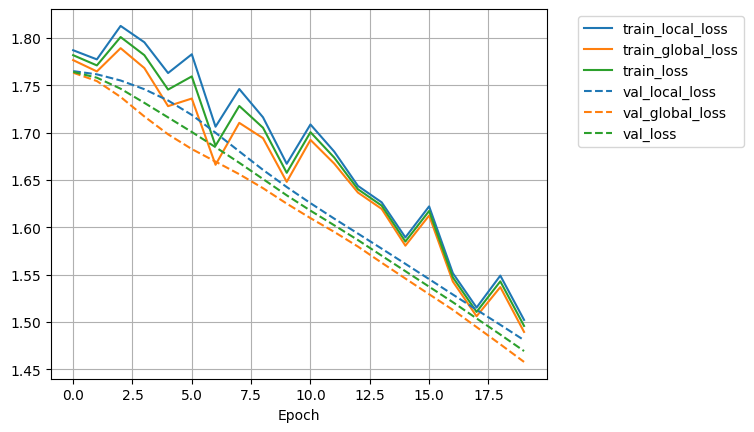

In [15]:
model.history_.plot_history(subset_term="loss")

## Infer results

In [16]:
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


## Save results

In [17]:
result.write(f"{BASE_DIR_PROJECT}/data/{DATA}_trained.h5ad")